# This Time Is Different? — the whole project in one Colab notebook
**Explainable deep learning of crisis transmission into Irish stock market volatility: the Global Financial Crisis, the Irish Sovereign Debt Crisis and COVID-19**

This notebook contains the complete analysis of the project — the twelve scripts in the GitHub repository (`code/01` … `code/12`) — rewritten as **one step-by-step notebook**. It uses the same structure, names and habits as the notebooks of the MSc machine-learning module: first *Data Preparation*, then each model with a *Method #1* (one model: building → training → testing → evaluation) and a *Method #2* (searching over settings or over all years), and finally a *Prediction*.

### How the class steps map onto this project

| Step in the class notebooks | What it becomes here | Section |
|---|---|---|
| Data Reading — `read_csv`, `head()`, `info()`, `describe()` | daily prices of the Irish, US, German and UK stock markets | 1.1 |
| DateTime — `to_datetime`, `.dt.year` (Bike Rental) | trading dates and the crisis windows | 1.2 |
| Data Cleaning — `fillna` with mean / mode | removing impossible prices; **no** filling (explained) | 1.3 |
| Data Encoding — `map`, `get_dummies` | turning prices into returns and volatility (feature building) | 1.4 |
| — | joining the three markets without using future information | 1.5 |
| Divide data to x and y | 6 inputs (x) and next week's log volatility (y) | 1.7 |
| Data scaling (x only) — `StandardScaler` | the same scaling, but fitted on the training years only | 1.8 |
| Data Splitting — `train_test_split` | a split **by time**, then a walk-forward over 17 years | 1.9 |
| Data balancing — `SMOTE` | not needed (explained) | 1.10 |
| Linear Regression — `statsmodels OLS` | the HAR benchmark | 3 |
| Method #1 / Method #2 (`GridSearchCV`) | one model / all years, or a grid of LSTM settings | 3–6 |
| Evaluation — `r2_score`, accuracy, precision… | QLIKE, MSE and the Diebold–Mariano test | 2 |
| Prediction — `predict(new1)` | the forecast for the week after the sample ends | 10 |

### How to run it in Google Colab
1. Upload the folder **`ThisTimeIsDifferent`** (it holds the data files and the saved results) to your Google Drive, inside **`MyDrive/DataSets/`** — the same place the class notebooks read their CSV files from.
2. In Colab: *File → Upload notebook* and choose this file.
3. *Runtime → Run all*. Colab asks for permission to open your Drive: allow it.

**Two settings (next cell).** With `FULL_RUN = False` the notebook runs in about 5–10 minutes: every light step is recomputed, and the two heavy steps (the 85 LSTM models and the SHAP analysis) are shown with one model (*Method #1*) and then loaded from the saved results. With `FULL_RUN = True` everything is recomputed from scratch; choose a GPU runtime (*Runtime → Change runtime type → T4 GPU*) and allow about 2–3 hours. Numbers recomputed on a GPU can differ in the last decimals from the saved (CPU) results.

> **Academic integrity.** This notebook was prepared with AI assistance, as declared in `notes/ai_use.md` in the repository. It is a working and study notebook, not dissertation text. The interpretation of the results and every sentence of the dissertation are written by the student.

In [1]:
# Settings: the only two lines you may want to change
FULL_RUN = False    # False = quick run (heavy steps loaded from saved results); True = recompute everything
USE_GPU = True      # only used when FULL_RUN = True and Colab provides a GPU

### Set-up
Colab already has pandas, numpy, scikit-learn, statsmodels, matplotlib and PyTorch. Two libraries are added: **arch** (GARCH models) and **captum** (SHAP explanations for PyTorch). Then Google Drive is connected, exactly as in the class notebooks (`/content/drive/MyDrive/DataSets/...`).

In [2]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch', 'captum'], check=True)
    from google.colab import drive
    drive.mount('/content/drive')
    DATA = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'
else:
    DATA = 'DataSets_for_Drive/ThisTimeIsDifferent/'     # the same folder, when the notebook runs on the laptop
OUT = 'outputs/'                                         # everything this notebook saves goes here
os.makedirs(OUT, exist_ok=True)
print('Data folder :', DATA)
print('Files       :', sorted(os.listdir(DATA)))

Data folder : DataSets_for_Drive/ThisTimeIsDifferent/
Files       : ['FRED_SPASTT01DEM661N.csv', 'FRED_SPASTT01IEM661N.csv', 'FRED_SPASTT01USM661N.csv', 'FTSE.csv', 'GDAXI.csv', 'GSPC.csv', 'ISEQ.csv', 'results']


In [3]:
# A small helper used throughout: compare what this notebook computes with the saved results of the project
import pandas as pd
from pandas import read_csv


def saved(name):
    '''Read a saved result table from the results folder (returns None if it is not there).'''
    path = DATA + 'results/' + name
    return read_csv(path) if os.path.exists(path) else None


def check(label, new, old):
    '''Largest absolute difference between a recomputed table/series and the saved one.'''
    if new.shape != old.shape:
        print(f'Check against the saved results ({label}): skipped (the tables have different sizes)')
        return
    diff = abs(new.to_numpy(dtype=float) - old.to_numpy(dtype=float)).max()
    print(f'Check against the saved results ({label}): largest difference = {diff:.2e}')

# 1. Data Preparation

## 1.1 Data Reading
**What the data are.** Four daily price files downloaded from Yahoo Finance with the Python library `yfinance` (1 Oct 2002 – 30 Dec 2025) and saved as CSV files, so that the study can always be repeated on exactly the same numbers (Yahoo sometimes revises its history):

| File | Market | Role in the study |
|---|---|---|
| `ISEQ.csv` | ISEQ Overall, Euronext Dublin (Ireland) | the market whose volatility we forecast; the **domestic** channel |
| `GSPC.csv` | S&P 500 (United States) | the **US** channel — origin of the Global Financial Crisis |
| `GDAXI.csv` | DAX (Germany) | the **euro** channel — core of the euro area |
| `FTSE.csv` | FTSE 100 (United Kingdom) | robustness check only (it overlaps the DAX, correlation 0.84) |

Each file has one row per trading day and the columns `Open, High, Low, Close, Volume`. As in the class notebooks, we read each file with `read_csv` and look at it with `head()`, `shape` and `info()`.

In [4]:
from pandas import read_csv
data1 = read_csv(DATA + 'ISEQ.csv')     # Ireland: ISEQ Overall (target market)
data2 = read_csv(DATA + 'GSPC.csv')     # United States: S&P 500
data3 = read_csv(DATA + 'GDAXI.csv')    # Euro area: DAX
data4 = read_csv(DATA + 'FTSE.csv')     # United Kingdom: FTSE 100 (robustness only)
data1.head()

,Unnamed: 0,Open,High,Low,Close,Volume
0,2002-10-01,3838.520020,3882.870117,3813.500000,3863.100098,0
1,2002-10-02,3864.139893,3942.629883,3859.600098,3926.350098,0
2,2002-10-03,3926.270020,3933.560059,3871.360107,3875.959961,0
3,2002-10-04,3875.870117,3887.030029,3840.580078,3842.899902,0
4,2002-10-07,3843.040039,3843.040039,3736.889893,3748.659912,0


In [5]:
print(data1.shape)
print(data2.shape)
print(data3.shape)
print(data4.shape)
data1.info()

(5898, 6)
(5850, 6)
(5903, 6)
(5873, 6)
<class 'pandas.DataFrame'>
RangeIndex: 5898 entries, 0 to 5897
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5898 non-null   str    
 1   Open        5898 non-null   float64
 2   High        5898 non-null   float64
 3   Low         5898 non-null   float64
 4   Close       5898 non-null   float64
 5   Volume      5898 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 334.2 KB


In [6]:
data1.describe()

,Open,High,Low,Close,Volume
count,5898.000000,5898.000000,5898.000000,5898.000000,5.898000e+03
mean,6125.242813,6172.992308,6079.435034,6127.030448,4.200325e+07
std,2273.729422,2286.243704,2261.533435,2275.313205,5.134741e+07
min,1916.380005,1975.420044,1880.359985,1916.380005,0.000000e+00
25%,4332.454956,4362.202393,4291.537354,4333.782593,1.697008e+07
50%,6259.369873,6303.215088,6204.570068,6260.689941,2.860650e+07
75%,7457.557373,7515.857544,7392.082520,7458.502441,4.982958e+07
max,13115.599609,13147.299805,13048.000000,13126.070312,1.628859e+09


**Optional — download fresh data instead of reading the saved files.** Only for curiosity: the results of the dissertation are based on the saved files, and fresh data can differ slightly because Yahoo revises its history.
```python
# import yfinance as yf
# data1 = yf.Ticker('^ISEQ').history(start='2002-10-01', end='2025-12-31', auto_adjust=False).reset_index()
```

## 1.2 Date-Time handling
In the Bike Rental notebook the text column `datetime` was turned into real dates with `to_datetime`, and parts such as the year were taken out with `.dt.year`. We do the same: the first column of each file holds the date as text; we convert it, name it `Date` and make it the **index** of the table. With dates as the index, pandas can select periods such as `data1.loc['2008']` or `data1.loc['2010-04-23':'2012-07-26']`, and it can line up the markets day by day.

In [7]:
from pandas import to_datetime
for df in (data1, data2, data3, data4):
    df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df['Date'] = to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
data1.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5898 entries, 2002-10-01 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5898 non-null   float64
 1   High    5898 non-null   float64
 2   Low     5898 non-null   float64
 3   Close   5898 non-null   float64
 4   Volume  5898 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 276.5 KB


In [8]:
# Trading days per year in Dublin (like data1['datetime'].dt.year in the Bike Rental notebook)
data1.index.year.value_counts().sort_index()

Date
2002     63
2003    253
2004    254
2005    253
2006    253
2007    254
2008    254
2009    251
2010    254
2011    253
2012    254
2013    254
2014    254
2015    254
2016    254
2017    253
2018    253
2019    253
2020    256
2021    255
2022    254
2023    254
2024    255
2025    253
Name: count, dtype: int64

## 1.3 Data Cleaning
In the Employees notebooks, missing ages were filled with the **mean** and missing distances with the **mode**. Prices are different: a missing price means the exchange was closed that day, and inventing a price would create a fake return. So we **do not fill** anything; we only remove rows that cannot be used (a missing close, or a price of zero or below). The check below shows that the saved files are already clean.

A second check explains an important design decision. A good volatility measure (Garman–Klass) needs the **opening** price. On Yahoo, the ISEQ 'open' is often just yesterday's close — a 'stale' open, not a real price. The table shows how often: in 2013–2019 three days out of four. That is why this project uses **closing prices only**.

In [9]:
for name, df in [('ISEQ', data1), ('S&P 500', data2), ('DAX', data3), ('FTSE', data4)]:
    print(name, ': missing closes =', df['Close'].isna().sum(), '| prices <= 0 =', (df['Close'] <= 0).sum())

data1 = data1.dropna(subset=['Close'])
data1 = data1[data1['Close'] > 0]
data2 = data2.dropna(subset=['Close'])
data2 = data2[data2['Close'] > 0]
data3 = data3.dropna(subset=['Close'])
data3 = data3[data3['Close'] > 0]
data4 = data4.dropna(subset=['Close'])
data4 = data4[data4['Close'] > 0]
print(data1.shape, data2.shape, data3.shape, data4.shape)

ISEQ : missing closes = 0 | prices <= 0 = 0
S&P 500 : missing closes = 0 | prices <= 0 = 0
DAX : missing closes = 0 | prices <= 0 = 0
FTSE : missing closes = 0 | prices <= 0 = 0
(5898, 5) (5850, 5) (5903, 5) (5873, 5)


In [10]:
# How often is the ISEQ 'open' just yesterday's close?
stale_open = (data1['Open'] - data1['Close'].shift(1)).abs() < 1e-9
for a, b in [('2003', '2006'), ('2007', '2012'), ('2013', '2019'), ('2020', '2025')]:
    print(a, '-', b, ': stale opens =', round(stale_open.loc[a:b].mean() * 100, 1), '%')

2003 - 2006 : stale opens = 8.3 %
2007 - 2012 : stale opens = 37.7 %
2013 - 2019 : stale opens = 75.4 %
2020 - 2025 : stale opens = 10.0 %


## 1.4 Feature building (the "Data Encoding" step)
In the class notebooks, *Data Encoding* turned text into numbers the model can use (`map`, `get_dummies`). Here the raw material is prices, and we turn them into the quantities the models need:

* **Log return** $r_t = \ln(P_t / P_{t-1})$ — the daily percentage change. It shows the **direction** of the move.
* **Squared return** $r_t^2$ — always positive; it shows the **size** of the move.
* **Target (y): forward 5-day realised variance** $RV5_t = r_{t+1}^2 + r_{t+2}^2 + r_{t+3}^2 + r_{t+4}^2 + r_{t+5}^2$ — how much the ISEQ will actually move over the **next five trading days**. The forecast is made after the close of day $t$, so everything on the right-hand side is in the future: this is what we try to predict.
* The models learn the **logarithm** of the target, $\ln RV5_t$, because volatility is very skewed (calm weeks are small numbers, crisis weeks are huge); logs make it more symmetric.
* **HAR ingredients** (used by the benchmark in Section 3): today's squared return (`rv_d`), the average of the last 5 days (`rv_w`, one week) and of the last 22 days (`rv_m`, one month).

In [11]:
from numpy import log, exp, sqrt
from pandas import DataFrame

ret = log(data1['Close']).diff()      # daily log return of the ISEQ (direction)
r2 = ret ** 2                          # squared return (size of the move)

dataset = DataFrame(index=data1.index)
dataset['ret'] = ret
dataset['r2'] = r2
dataset['rv5_fwd'] = r2.shift(-1) + r2.shift(-2) + r2.shift(-3) + r2.shift(-4) + r2.shift(-5)   # target: next 5 days
dataset['log_rv5_fwd'] = log(dataset['rv5_fwd'])
dataset['rv_d'] = r2                      # HAR: today
dataset['rv_w'] = r2.rolling(5).mean()    # HAR: last week
dataset['rv_m'] = r2.rolling(22).mean()   # HAR: last month
dataset.head(8)

,ret,r2,rv5_fwd,log_rv5_fwd,rv_d,rv_w,rv_m
Date,,,,,,,
2002-10-01,NaN,NaN,0.001136,-6.780199,NaN,NaN,NaN
2002-10-02,0.016240,0.000264,0.001831,-6.302895,0.000264,NaN,NaN
2002-10-03,-0.012917,0.000167,0.001708,-6.372562,0.000167,NaN,NaN
2002-10-04,-0.008566,0.000073,0.003915,-5.543037,0.000073,NaN,NaN
2002-10-07,-0.024829,0.000616,0.003316,-5.709106,0.000616,NaN,NaN
2002-10-08,-0.003951,0.000016,0.004541,-5.394515,0.000016,0.000227,NaN
2002-10-09,-0.030963,0.000959,0.003683,-5.603908,0.000959,0.000366,NaN
2002-10-10,0.006605,0.000044,0.004022,-5.516028,0.000044,0.000342,NaN


## 1.5 Joining the three markets without looking into the future
The markets close at different times (Irish time): Dublin and London at 16:30, Frankfurt at 16:30, **New York at about 21:00**. The forecast for Dublin is issued at 08:00 the next morning, so the closes of all markets on day $t$ are already known and may be used — but nothing from day $t+1$.

`merge_asof(..., direction='backward')` attaches to each Irish trading day the **latest foreign value dated on or before that day**. When a foreign market was closed on an Irish trading day (for example a US holiday), the last known value is carried forward. For each market we build its return and squared return (`us_ret`, `us_r2`, `euro_ret`, `euro_r2`, and `uk_ret`, `uk_r2` for the robustness check).

In [12]:
from pandas import merge_asof
for df, name in [(data2, 'us'), (data3, 'euro'), (data4, 'uk')]:
    fr = log(df['Close']).diff()
    feat = DataFrame({name + '_ret': fr, name + '_r2': fr ** 2}).sort_index()
    dataset = merge_asof(dataset.sort_index(), feat, left_index=True, right_index=True, direction='backward')
    carried = (~dataset.index.isin(df.index)).mean()
    print(name, ': Irish days that use a carried-forward value =', round(carried * 100, 1), '%')
dataset.info()

us : Irish days that use a carried-forward value = 2.6 %
euro : Irish days that use a carried-forward value = 0.9 %
uk : Irish days that use a carried-forward value = 0.9 %
<class 'pandas.DataFrame'>
DatetimeIndex: 5898 entries, 2002-10-01 to 2025-12-30
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ret          5897 non-null   float64
 1   r2           5897 non-null   float64
 2   rv5_fwd      5893 non-null   float64
 3   log_rv5_fwd  5893 non-null   float64
 4   rv_d         5897 non-null   float64
 5   rv_w         5893 non-null   float64
 6   rv_m         5876 non-null   float64
 7   us_ret       5897 non-null   float64
 8   us_r2        5897 non-null   float64
 9   euro_ret     5897 non-null   float64
 10  euro_r2      5897 non-null   float64
 11  uk_ret       5897 non-null   float64
 12  uk_r2        5897 non-null   float64
dtypes: float64(13)
memory usage: 774.1 KB


## 1.6 Sample period and evaluation windows
* The **main sample** runs from **2 January 2003 to 31 August 2023**. It starts after the dot-com crash and stops before the ISEQ lost three of its largest companies (CRH in September 2023, then Flutter and Smurfit), which changed what the index measures.
* The **evaluation windows** are the crises (and two test events) that the study compares. They are used **only to split the results** afterwards — the models never see them, just as the class models never saw `y_test` while training.

In [13]:
SAMPLE_START, SAMPLE_END = '2003-01-01', '2023-08-31'
HORIZON = 5
TEST_YEARS = range(2007, 2024)
WINDOWS = {                                   # evaluation windows (never model inputs)
    'Global Financial Crisis': ('2007-08-09', '2009-03-09'),
    'Irish sovereign debt crisis': ('2010-04-23', '2012-07-26'),
    'COVID-19': ('2020-02-19', '2020-06-30'),
    'War / energy shock 2022': ('2022-02-10', '2022-10-31'),
    'Brexit referendum': ('2016-06-01', '2016-07-31'),
}

dataset = dataset.loc[SAMPLE_START:]
main_sample = dataset.loc[:SAMPLE_END].dropna()
print('Main sample, complete rows:', len(main_sample))
print('Zero-return days:', (main_sample['r2'] == 0).sum())
c = dataset.loc[:SAMPLE_END, ['ret', 'us_ret', 'euro_ret', 'uk_ret']].corr()
print('Correlation of daily returns with the ISEQ: US', round(c.loc['ret', 'us_ret'], 2),
      '| euro', round(c.loc['ret', 'euro_ret'], 2), '| UK', round(c.loc['ret', 'uk_ret'], 2),
      '| euro-UK', round(c.loc['euro_ret', 'uk_ret'], 2))

Main sample, complete rows: 5243
Zero-return days: 2
Correlation of daily returns with the ISEQ: US 0.48 | euro 0.69 | UK 0.71 | euro-UK 0.83


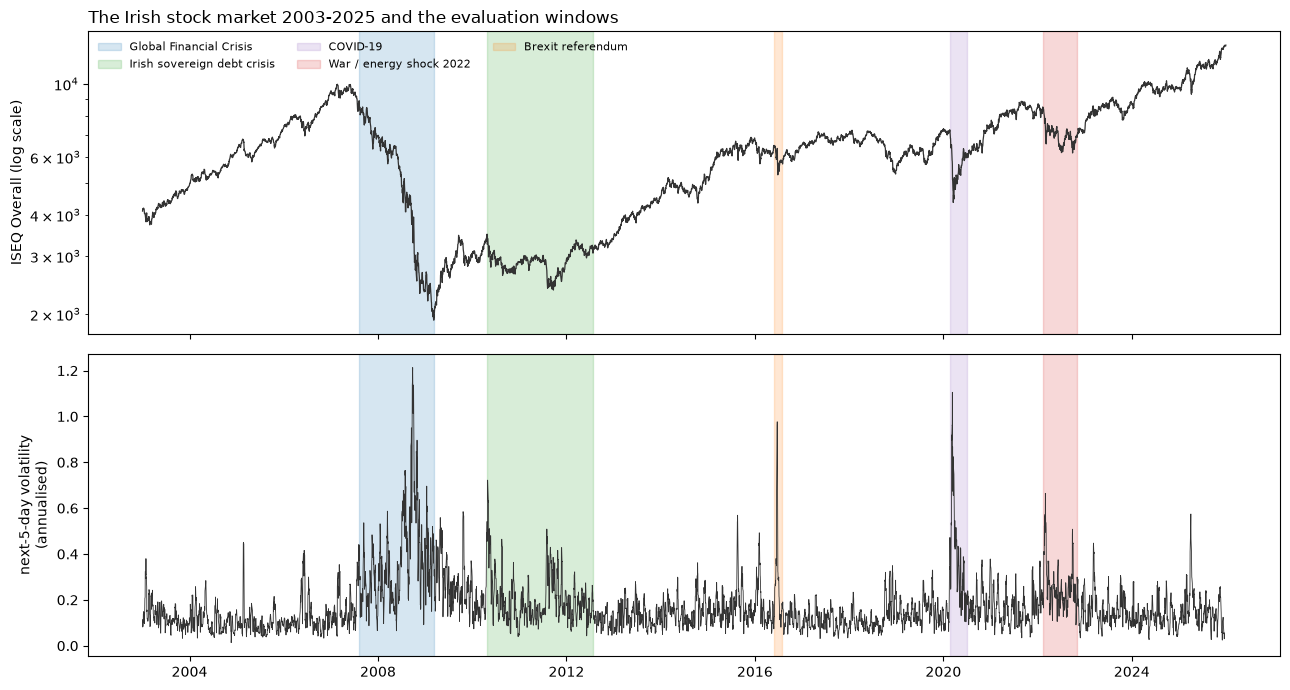

In [14]:
import matplotlib.pyplot as plt
from pandas import Timestamp

ann_vol = sqrt(dataset['rv5_fwd'] * 252 / 5)          # annualised volatility of the next 5 days
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax1.plot(data1.loc[SAMPLE_START:, 'Close'], color='#333', lw=0.9)
ax1.set_yscale('log')
ax1.set_ylabel('ISEQ Overall (log scale)')
ax2.plot(ann_vol, color='#333', lw=0.6)
ax2.set_ylabel('next-5-day volatility\n(annualised)')
for ax in (ax1, ax2):
    for (name, (a, b)), col in zip(WINDOWS.items(), ['#1f77b4', '#2ca02c', '#9467bd', '#d62728', '#ff7f0e']):
        ax.axvspan(Timestamp(a), Timestamp(b), color=col, alpha=0.18, label=name if ax is ax1 else None)
ax1.legend(fontsize=8, frameon=False, ncol=3)
ax1.set_title('The Irish stock market 2003-2025 and the evaluation windows', loc='left')
plt.tight_layout()
plt.show()

## 1.7 Divide data to x and y
As in every class notebook, we separate the **inputs (x)** from the **target (y)**:

* **x** — six inputs per day, two per market: the return (direction) and the log squared return (size) of the ISEQ, the S&P 500 and the DAX. The squared returns are put in logs, with a tiny floor ($10^{-8}$) so that the two days with a zero return do not give $\ln 0$.
* **y** — `log_rv5_fwd`, the log of next week's realised variance.

The LSTM does not see one row at a time: it reads the last **22 trading days** (about one month) of these six inputs, so each forecast uses a small 22 × 6 table (Section 5).

In [15]:
INPUTS = ['ret', 'r2', 'us_ret', 'us_r2', 'euro_ret', 'euro_r2']
model_data = dataset.loc[:SAMPLE_END].copy()
for col in ['r2', 'us_r2', 'euro_r2']:
    model_data[col] = log(model_data[col].clip(lower=1e-8))   # squared returns in logs
model_data = model_data.dropna(subset=INPUTS)

x = model_data[INPUTS]
y = model_data['log_rv5_fwd']
print(x.shape)
print(y.shape)

(5243, 6)
(5243,)


## 1.8 Data scaling (x only)
In class, `StandardScaler().fit_transform(x)` rescaled every input to mean 0 and standard deviation 1 **before** splitting. With time series that would be a mistake: the mean and standard deviation of the whole sample include the crisis years, so information from the future would leak into the training data.

The rule in this project is therefore: **fit the scaler on the training years only**, then apply it to the test year. The cell below shows it for the first split (train up to 2006, test 2007). The LSTM code in Section 5 does exactly this for every year, with the same formula (it scales the target y as well, and undoes the scaling after predicting).

In [16]:
from sklearn.preprocessing import StandardScaler
x_train_demo = x.loc[:'2006-12-31']
scaler = StandardScaler().fit(x_train_demo)          # learns mean and standard deviation from 2003-2006 only
x_scaled = DataFrame(scaler.transform(x), index=x.index, columns=INPUTS)
print('Training years (2003-2006): mean ~0, std ~1')
print(x_scaled.loc[:'2006'].describe().round(2).loc[['mean', 'std']])
print('Crisis year 2008 on the same scale: much larger spread')
print(x_scaled.loc['2008'].describe().round(2).loc[['mean', 'std']])

Training years (2003-2006): mean ~0, std ~1
      ret   r2  us_ret  us_r2  euro_ret  euro_r2
mean  0.0  0.0     0.0   -0.0      -0.0     -0.0
std   1.0  1.0     1.0    1.0       1.0      1.0
Crisis year 2008 on the same scale: much larger spread
       ret    r2  us_ret  us_r2  euro_ret  euro_r2
mean -0.62  1.08   -0.32   0.84     -0.21     0.44
std   3.62  1.12    3.31   1.16      1.89     1.01


## 1.9 Data Splitting
In class, `train_test_split(x, y, test_size=0.10, random_state=10)` **shuffled** the rows before splitting. For employees that is fine; for time series it is not — a shuffled split trains on 2009 and tests on 2008, i.e. it forecasts the past with the future.

Two rules replace it:
1. **Split by time** (`shuffle=False`): the training rows always come before the test rows.
2. **Walk-forward with annual refits**: train on all years up to 31 December, forecast the whole next year, add that year to the training data, and repeat — 17 test years, 2007 to August 2023. This is exactly what a forecaster could have done in real time.

Two more details prevent leakage: the last 5 training days are dropped (their 5-day targets reach into the test year), and inside each training period the **last 12 months are kept apart as validation** data for the LSTM (to decide when to stop training).

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x.loc[:'2007-12-31'], y.loc[:'2007-12-31'],
                                                    test_size=0.20, shuffle=False)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print('training ends', x_train.index[-1].date(), '| testing starts', x_test.index[0].date())

(1013, 6)
(254, 6)
(1013,)
(254,)
training ends 2006-12-29 | testing starts 2007-01-02


In [18]:
# The walk-forward design: one row per refit
rows = []
for year in TEST_YEARS:
    train = model_data.loc[:f'{year - 1}-12-31']
    test = model_data.loc[f'{year}-01-01':f'{year}-12-31'].dropna(subset=['log_rv5_fwd'])
    rows.append({'test year': year, 'training days': len(train), 'test days': len(test),
                 'training period': f"{train.index[0].date()} to {train.index[-1].date()}"})
DataFrame(rows).set_index('test year')

,training days,test days,training period
test year,,,
2007,1013,254,2003-01-02 to 2006-12-29
2008,1267,254,2003-01-02 to 2007-12-31
2009,1521,251,2003-01-02 to 2008-12-31
2010,1772,254,2003-01-02 to 2009-12-31
2011,2026,253,2003-01-02 to 2010-12-31
2012,2279,254,2003-01-02 to 2011-12-30
2013,2533,254,2003-01-02 to 2012-12-31
2014,2787,254,2003-01-02 to 2013-12-31
2015,3041,254,2003-01-02 to 2014-12-31


## 1.10 Data balancing
In the Employees notebooks `SMOTE` created extra examples of the rare class (employees who left), because a classifier trained on 85% 'stayed' learns to ignore the rest. Here the target is a **number** (a regression, not a classification), so there are no classes to balance. Crisis weeks are rare, but copying or inventing crisis days would break the time order and create days that never happened. Instead, the study **evaluates each crisis window separately** (Section 2), so good calm-period accuracy cannot hide poor crisis accuracy.

# 2. Evaluation tools
In class, a regressor was scored with `r2_score` and a classifier with accuracy, precision, recall and F1. Volatility forecasts need their own tools:

* **QLIKE** (the main score): $\text{QLIKE} = \dfrac{RV}{F} - \ln\dfrac{RV}{F} - 1$, averaged over days, where $RV$ is the realised and $F$ the forecast variance. It is 0 for a perfect forecast and larger for worse ones. It punishes **under-prediction** (saying 'calm' before a storm) more than over-prediction, and — unlike the squared error — it still ranks models correctly when the 'true' volatility is only measured with noise (Patton, 2011).
* **MSE** (second score): the average squared error.
* **Diebold–Mariano test** (with the Harvey–Leybourne–Newbold small-sample correction): is the average difference in loss between two models really different from zero, or could it be luck? Because 5-day forecasts overlap, neighbouring days are correlated, so the test uses a long-run variance with 4 lags. A **negative** mean difference means the first model is more accurate; $p < 0.05$ means the difference is statistically significant.
* **By window**: every score is reported for all test days, calm days and each crisis window.

In [19]:
import numpy as np
from scipy import stats
from pandas import Series


def window_of(dates):
    '''Label each date with its evaluation window ('calm' if none).'''
    lab = Series('calm', index=dates)
    for name, (a, b) in WINDOWS.items():
        lab[(dates >= a) & (dates <= b)] = name
    return lab


def qlike(realised, forecast):
    ratio = np.asarray(realised) / np.asarray(forecast)
    return ratio - np.log(ratio) - 1


def mse(realised, forecast):
    return (np.asarray(realised) - np.asarray(forecast)) ** 2


def dm_hln(loss_a, loss_b, h=HORIZON):
    '''Diebold-Mariano test with the HLN correction. Negative mean_diff = model A more accurate.'''
    d = np.asarray(loss_a) - np.asarray(loss_b)
    d = d[~np.isnan(d)]
    n = len(d)
    dbar = d.mean()
    dc = d - dbar
    gamma = [np.dot(dc[k:], dc[:n - k]) / n for k in range(h)]
    lrv = gamma[0] + 2 * sum(gamma[1:])
    if lrv <= 0:
        lrv = gamma[0] + 2 * sum((1 - k / h) * gamma[k] for k in range(1, h))
    dm = dbar / np.sqrt(lrv / n)
    hln = dm * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    p = 2 * stats.t.sf(abs(hln), df=n - 1)
    return {'n': n, 'mean_diff': dbar, 'stat': hln, 'p_value': p}


def loss_table(df, models, realised='rv5_fwd'):
    '''Mean QLIKE and MSE per model, for all test days and each window.'''
    rows = []
    groups = [('All test days (2007 - Aug 2023)', df)] + [(w, g) for w, g in df.groupby('window')]
    for name, g in groups:
        row = {'window': name, 'days': len(g)}
        for m in models:
            row[f'QLIKE {m}'] = qlike(g[realised], g[m]).mean()
            row[f'MSE {m} (x1e6)'] = mse(g[realised], g[m]).mean() * 1e6
        rows.append(row)
    order = ['All test days (2007 - Aug 2023)', 'calm', *WINDOWS]
    out = DataFrame(rows).set_index('window')
    return out.reindex([w for w in order if w in out.index])

# 3. Benchmark 1 — HAR (Linear Regression with OLS)
The HAR model (Corsi, 2009) is a **linear regression**, estimated with `statsmodels` `OLS` exactly as in the Simple Salary notebook (`add_constant`, `OLS(y, x)`, `.fit()`, `.summary()`, `.params`). It says that next week's (log) volatility depends on today's, last week's and last month's volatility — like traders who look at different horizons:

$$\ln RV5_t = \beta_0 + \beta_d \ln RV_{d,t} + \beta_w \ln RV_{w,t} + \beta_m \ln RV_{m,t} + \varepsilon_t$$

Because the model is fitted in logs, the forecast is turned back into a variance with $\exp(\cdot)$ and multiplied by a **smearing factor** (Duan) — the average of $\exp(\text{residual})$ — because $\exp$ of an average log is too small on average.

## Method #1 (one year: train on 2003–2006, test on 2007)
### Modelling

In [20]:
from statsmodels.api import OLS, add_constant

bench_data = dataset.loc[:SAMPLE_END]
x_har = log(bench_data[['rv_d', 'rv_w', 'rv_m']].clip(lower=1e-8))
y_har = log(bench_data['rv5_fwd'])

train_days = bench_data.loc[:'2006-12-31'].dropna(subset=['rv5_fwd', 'rv_m']).index[:-HORIZON]   # drop last 5 days
test_days = bench_data.loc['2007-01-01':'2007-12-31'].dropna(subset=['rv5_fwd']).index
print(len(train_days), 'training days |', len(test_days), 'test days')

x_train = add_constant(x_har.loc[train_days])
model = OLS(y_har.loc[train_days], x_train)          # building
best_model = model.fit()                              # training
print(best_model.summary())

1008 training days | 254 test days
                            OLS Regression Results                            
Dep. Variable:                rv5_fwd   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     42.64
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           6.10e-26
Time:                        00:53:50   Log-Likelihood:                -1278.4
No. Observations:                1008   AIC:                             2565.
Df Residuals:                    1004   BIC:                             2584.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.

In [21]:
best_model.params

const   -3.833383
rv_d     0.006900
rv_w     0.035312
rv_m     0.425291
dtype: float64

Reading the coefficients as an equation (as in the Salary notebook: *Salary = B0 + B1 × YearsExperience*):

$\ln RV5 = \beta_0 + \beta_d \cdot \ln(\text{today}) + \beta_w \cdot \ln(\text{last week}) + \beta_m \cdot \ln(\text{last month})$, with the numbers printed above. The monthly term carries the most weight: the slow level of volatility matters most.

In [22]:
smear = np.mean(np.exp(best_model.resid))                                             # Duan smearing factor
y_pred1 = exp(best_model.predict(add_constant(x_har.loc[test_days], has_constant='add'))) * smear   # testing
print('smearing factor =', round(smear, 3))
y_pred1.head()

smearing factor = 1.493


Date
2007-01-02    0.000363
2007-01-03    0.000364
2007-01-04    0.000356
2007-01-05    0.000350
2007-01-08    0.000362
dtype: float64

### Evaluation

In [23]:
QLIKE1 = qlike(bench_data.loc[test_days, 'rv5_fwd'], y_pred1).mean()
print('QLIKE (HAR, 2007) =', round(QLIKE1, 3))
print('R2 of the HAR regression (training years) =', round(best_model.rsquared * 100, 2), '%')

QLIKE (HAR, 2007) = 0.659
R2 of the HAR regression (training years) = 11.3 %


## Method #2 (walk-forward: one refit per year, 2007–2023)
The same three steps — building, training, testing — repeated for every test year on an expanding window.

In [24]:
har_forecasts, har_params = [], []
for year in TEST_YEARS:
    start = Timestamp(f'{year}-01-01')
    end = min(Timestamp(f'{year}-12-31'), Timestamp(SAMPLE_END))
    test_days = bench_data.loc[start:end].dropna(subset=['rv5_fwd']).index
    train_days = bench_data.loc[:start - pd.Timedelta(days=1)].dropna(subset=['rv5_fwd', 'rv_m']).index[:-HORIZON]

    model = OLS(y_har.loc[train_days], add_constant(x_har.loc[train_days]))                   # building
    best_model = model.fit()                                                                  # training
    smear = np.mean(np.exp(best_model.resid))
    y_pred = exp(best_model.predict(add_constant(x_har.loc[test_days], has_constant='add'))) * smear   # testing

    har_forecasts.append(y_pred)
    har_params.append({'test year': year, 'R2': best_model.rsquared, 'monthly weight': best_model.params['rv_m']})
    print(year, ':', len(test_days), 'test days | R2 =', round(best_model.rsquared, 2))

har_fc = pd.concat(har_forecasts)

2007 : 254 test days | R2 = 0.11
2008 : 254 test days | R2 = 0.25
2009 : 251 test days | R2 = 0.53
2010 : 254 test days | R2 = 0.57
2011 : 253 test days | R2 = 0.53
2012 : 254 test days | R2 = 0.52


2013 : 254 test days | R2 = 0.5
2014 : 254 test days | R2 = 0.49
2015 : 254 test days | R2 = 0.47
2016 : 254 test days | R2 = 0.46


2017 : 253 test days | R2 = 0.43
2018 : 253 test days | R2 = 0.43


2019 : 253 test days | R2 = 0.43
2020 : 256 test days | R2 = 0.42


2021 : 255 test days | R2 = 0.43
2022 : 254 test days | R2 = 0.41
2023 : 170 test days | R2 = 0.41


# 4. Benchmark 2 — GARCH(1,1)
GARCH (Bollerslev, 1986) is the industry-standard volatility model and is famously hard to beat (Hansen & Lunde, 2005). It says tomorrow's variance is a bit of a long-run level, plus a reaction to today's surprise, plus most of today's variance carried forward:

$$\sigma^2_{t+1} = \omega + \alpha\,\varepsilon_t^2 + \beta\,\sigma_t^2$$

* $\alpha$ = reaction to news, $\beta$ = memory; $\alpha + \beta$ close to 1 means shocks fade slowly.
* Errors follow a **Student-t** distribution (fat tails: crashes are more likely than a bell curve says).
* The 5-day forecast is the **sum of the 1- to 5-day-ahead** variance forecasts.
* Estimated by maximum likelihood with the `arch` library on daily ISEQ returns in per cent (×100 for numerical stability). Each year the parameters are re-estimated on data before 1 January (`last_obs`) and then kept fixed, while the forecast is updated every day with the newest return.

## Method #1 (one year: 2007)
### Modelling

In [25]:
from arch import arch_model

returns = bench_data['ret'].dropna() * 100
test_days = bench_data.loc['2007-01-01':'2007-12-31'].dropna(subset=['rv5_fwd']).index

GARCH_model1 = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t')   # building
GARCH_fit1 = GARCH_model1.fit(last_obs=Timestamp('2007-01-01'), disp='off')              # training (data before 2007)
print(GARCH_fit1.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1154.12
Distribution:      Standardized Student's t   AIC:                           2318.24
Method:                  Maximum Likelihood   BIC:                           2342.85
                                              No. Observations:                 1013
Date:                      Thu, Oct 01 2026   Df Residuals:                     1012
Time:                              00:53:51   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [26]:
fc1 = GARCH_fit1.forecast(horizon=HORIZON, start=test_days[0], reindex=False)          # testing
y_pred1 = fc1.variance.loc[test_days].sum(axis=1) / 1e4                               # 5-day variance, decimal units
print('persistence alpha + beta =', round(GARCH_fit1.params['alpha[1]'] + GARCH_fit1.params['beta[1]'], 3))
y_pred1.head()

persistence alpha + beta = 0.957


Date
2007-01-02    0.000292
2007-01-03    0.000323
2007-01-04    0.000310
2007-01-05    0.000295
2007-01-08    0.000314
dtype: float64

### Evaluation

In [27]:
QLIKE1 = qlike(bench_data.loc[test_days, 'rv5_fwd'], y_pred1).mean()
print('QLIKE (GARCH, 2007) =', round(QLIKE1, 3))

QLIKE (GARCH, 2007) = 0.518


## Method #2 (walk-forward, 2007–2023)

In [28]:
garch_forecasts, garch_params = [], []
for year in TEST_YEARS:
    start = Timestamp(f'{year}-01-01')
    end = min(Timestamp(f'{year}-12-31'), Timestamp(SAMPLE_END))
    test_days = bench_data.loc[start:end].dropna(subset=['rv5_fwd']).index

    GARCH_model = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t')   # building
    GARCH_fit = GARCH_model.fit(last_obs=start, disp='off')                                 # training
    fc = GARCH_fit.forecast(horizon=HORIZON, start=test_days[0], reindex=False)             # testing
    garch_forecasts.append(fc.variance.loc[test_days].sum(axis=1) / 1e4)
    p = GARCH_fit.params
    garch_params.append({'test year': year, 'alpha': p['alpha[1]'], 'beta': p['beta[1]'],
                         'persistence': p['alpha[1]'] + p['beta[1]'], 'nu (tails)': p['nu']})
    print(year, ': alpha + beta =', round(p['alpha[1]'] + p['beta[1]'], 3), '| nu =', round(p['nu'], 1))

garch_fc = pd.concat(garch_forecasts)

2007 : alpha + beta = 0.957 | nu = 6.2


2008 : alpha + beta = 0.977 | nu = 6.2


2009 : alpha + beta = 0.994 | nu = 6.5


2010 : alpha + beta = 0.999 | nu = 7.0
2011 : alpha + beta = 0.998 | nu = 6.8


2012 : alpha + beta = 0.999 | nu = 7.3


...

2015 : alpha + beta = 0.995 | nu = 8.2
2016 : alpha + beta = 0.995 | nu = 8.3


2017 : alpha + beta = 0.992 | nu = 7.7
2018 : alpha + beta = 0.991 | nu = 7.7


2019 : alpha + beta = 0.99 | nu = 7.8
2020 : alpha + beta = 0.989 | nu = 8.0


2021 : alpha + beta = 0.99 | nu = 7.7
2022 : alpha + beta = 0.989 | nu = 7.3


2023 : alpha + beta = 0.99 | nu = 7.4


## The two benchmarks together (and a naive reference)
The **naive** forecast (next week will look like last week: `rv_w × 5`) is shown only as a sanity check. Then both benchmarks are scored and compared with the Diebold–Mariano test.

In [29]:
test_index = har_fc.index
bench_fc = DataFrame({'rv5_fwd': bench_data.loc[test_index, 'rv5_fwd'], 'HAR': har_fc, 'GARCH': garch_fc,
                      'Naive': bench_data.loc[test_index, 'rv_w'] * HORIZON})
bench_fc['window'] = window_of(bench_fc.index)
bench_fc.to_csv(OUT + 'benchmark_forecasts.csv')

old = saved('benchmark_forecasts.csv')
if old is not None:
    check('benchmark forecasts', bench_fc[['HAR', 'GARCH', 'Naive']], old[['HAR', 'GARCH', 'Naive']])

losses_bench = loss_table(bench_fc, ['HAR', 'GARCH', 'Naive'])
losses_bench.filter(like='QLIKE').round(3)

Check against the saved results (benchmark forecasts): largest difference = 2.62e-07


,QLIKE HAR,QLIKE GARCH,QLIKE Naive
window,,,
All test days (2007 - Aug 2023),0.414,0.380,0.802
calm,0.360,0.351,0.802
Global Financial Crisis,0.676,0.401,0.834
Irish sovereign debt crisis,0.380,0.374,0.802
COVID-19,0.763,0.700,1.053
War / energy shock 2022,0.282,0.290,0.506
Brexit referendum,1.973,1.941,1.264


In [30]:
t = dm_hln(qlike(bench_fc['rv5_fwd'], bench_fc['HAR']), qlike(bench_fc['rv5_fwd'], bench_fc['GARCH']))
print('Diebold-Mariano, QLIKE, HAR vs GARCH: mean difference =', round(t['mean_diff'], 4),
      '| statistic =', round(t['stat'], 2), '| p =', round(t['p_value'], 4))
print('(positive = HAR less accurate than GARCH)')

Diebold-Mariano, QLIKE, HAR vs GARCH: mean difference = 0.0342 | statistic = 3.39 | p = 0.0007
(positive = HAR less accurate than GARCH)


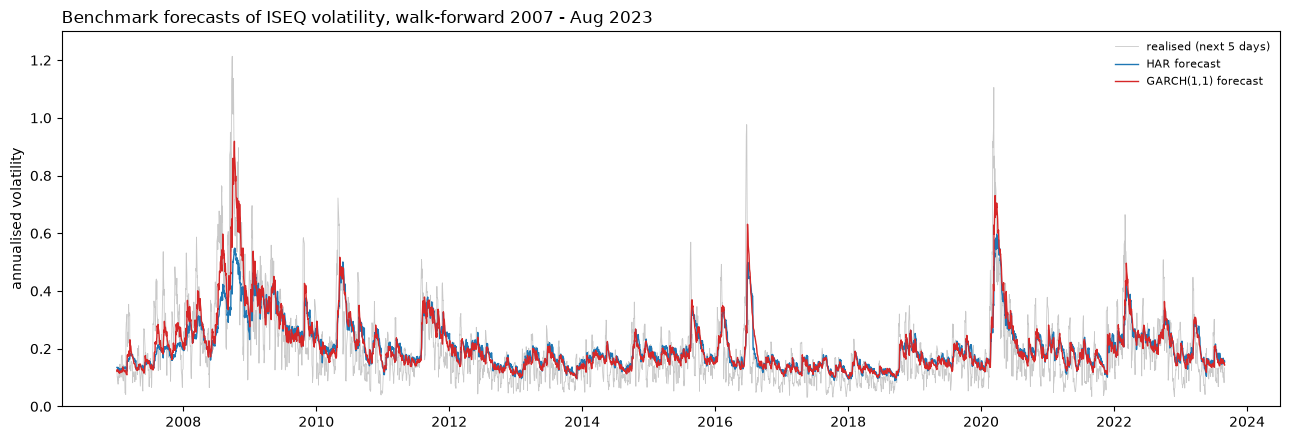

In [31]:
ann = lambda s: sqrt(s * 252 / HORIZON)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(ann(bench_fc['rv5_fwd']), color='#c9c9c9', lw=0.6, label='realised (next 5 days)')
ax.plot(ann(bench_fc['HAR']), color='#1f77b4', lw=1.0, label='HAR forecast')
ax.plot(ann(bench_fc['GARCH']), color='#d62728', lw=1.0, label='GARCH(1,1) forecast')
ax.set_ylim(0, 1.3)
ax.set_ylabel('annualised volatility')
ax.legend(frameon=False, fontsize=8)
ax.set_title('Benchmark forecasts of ISEQ volatility, walk-forward 2007 - Aug 2023', loc='left')
plt.tight_layout()
plt.show()

# 5. The LSTM (deep learning)
### How the LSTM works, in short
A **Long Short-Term Memory** network (Hochreiter & Schmidhuber, 1997) is a neural network that reads a sequence one step at a time and keeps a **memory** (the *cell state*). Three learned **gates** decide at every step what to forget, what new information to store and what to output. Here the sequence is the last **22 trading days**, and on each day the network sees the **6 inputs** of Section 1.7. After the 22nd day, a final linear layer turns the memory into one number: the forecast of next week's (standardised) log volatility.

| Element | Choice | Why |
|---|---|---|
| Inputs | 22 days × 6 inputs (direction and size for ISEQ, S&P 500, DAX) | recent history of all three channels |
| Network | 2 LSTM layers × 64 units → dropout 0.2 → linear output | chosen by the grid search (Method #2) |
| Target | standardised $\ln RV5$ | symmetric; always positive after converting back |
| Training | Adam, learning rate 0.001, batches of 64, up to 200 epochs | standard settings |
| Early stopping | stop when the validation loss has not improved for 15 epochs | prevents over-fitting |
| Validation | the last 12 months of each training period | decides when to stop; estimates the smearing factor |
| Seeds | 5 random starts per year; the forecast is their average | reduces randomness from any one run |

### Building blocks
The cell below defines the network (`LSTMVol`), how the 22-day windows are cut out of the data (`windows`), which rows are used for fitting and validation (`split_positions`), the training loop with early stopping (`fit_model`) and the forecast (`forecast`). Inside `fit_model`, the inputs are standardised with the mean and standard deviation of the **fitting rows only** — the StandardScaler idea of Section 1.8 — and the forecast is converted back with $\exp(\cdot)$ and a smearing factor estimated on the validation year.

In [32]:
import torch
from torch import nn

torch.set_num_threads(2)            # same as the original runs (two threads per model)
DROPOUT, LR, BATCH, MAX_EPOCHS, PATIENCE = 0.2, 1e-3, 64, 200, 15
DEVICE = 'cuda' if (FULL_RUN and USE_GPU and torch.cuda.is_available()) else 'cpu'
print('Device for the full run:', DEVICE)


class LSTMVol(nn.Module):
    def __init__(self, n_in, hidden, layers):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True,
                            dropout=DROPOUT if layers > 1 else 0.0)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)                               # read the 22-day sequence
        return self.head(self.drop(out[:, -1])).squeeze(-1)  # forecast from the last day's memory


def windows(X, positions, lookback):
    '''Stack the look-back window ending at each position: shape (n, lookback, n_inputs).'''
    return np.stack([X[p - lookback + 1: p + 1] for p in positions]).astype(np.float32)


def split_positions(d, train_end, lookback):
    '''Rows for fitting and for validation (last 12 months) inside the training period ending at train_end.'''
    dates = d.index
    has_y = d['log_rv5_fwd'].notna().to_numpy()
    ok = np.arange(len(d)) >= lookback - 1
    train_end = Timestamp(train_end)
    val_start = train_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
    fit = np.where(ok & has_y & (dates < val_start))[0][:-HORIZON]                           # 5-day gap
    val = np.where(ok & has_y & (dates >= val_start) & (dates <= train_end))[0][:-HORIZON]   # 5-day gap
    return fit, val


def fit_model(d, train_end, lookback, hidden, layers, seed, inputs=INPUTS, device='cpu'):
    '''Build and train one LSTM on data up to train_end (returns everything needed to forecast).'''
    torch.manual_seed(seed)
    np.random.seed(seed)
    fit_pos, val_pos = split_positions(d, train_end, lookback)
    fit_dates = d.index[fit_pos]
    mu, sd = d.loc[:fit_dates[-1], inputs].mean(), d.loc[:fit_dates[-1], inputs].std()      # scaling: training rows only
    y_mu, y_sd = d['log_rv5_fwd'].iloc[fit_pos].mean(), d['log_rv5_fwd'].iloc[fit_pos].std()
    X = ((d[inputs] - mu) / sd).to_numpy(np.float32)
    yv_all = ((d['log_rv5_fwd'] - y_mu) / y_sd).to_numpy(np.float32)
    Xf, yf = torch.tensor(windows(X, fit_pos, lookback)).to(device), torch.tensor(yv_all[fit_pos]).to(device)
    Xv, yv = torch.tensor(windows(X, val_pos, lookback)).to(device), torch.tensor(yv_all[val_pos]).to(device)

    model = LSTMVol(len(inputs), hidden, layers).to(device)                              # building
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()
    best, best_state, wait, epoch = np.inf, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):                                                 # training
        model.train()
        perm = torch.randperm(len(Xf))
        for b in range(0, len(Xf), BATCH):
            j = perm[b:b + BATCH].to(device)
            opt.zero_grad()
            loss_fn(model(Xf[j]), yf[j]).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xv), yv).item()
        if v < best - 1e-4:
            best, best_state, wait = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= PATIENCE:                                                           # early stopping
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pv = model(Xv).cpu().numpy() * y_sd + y_mu
    smear = float(np.mean(np.exp(d['log_rv5_fwd'].iloc[val_pos].to_numpy() - pv)))         # smearing on validation
    return {'model': model, 'lookback': lookback, 'inputs': list(inputs), 'mu': mu, 'sd': sd,
            'y_mu': y_mu, 'y_sd': y_sd, 'smear': smear, 'epochs': epoch, 'val_loss': best, 'seed': seed,
            'train_end': str(train_end), 'device': device}


def forecast(bundle, d, dates):
    '''Variance forecasts (decimal units) for the given dates, using data up to each date only.'''
    X = ((d[bundle['inputs']] - bundle['mu']) / bundle['sd']).to_numpy(np.float32)
    pos = d.index.get_indexer(pd.DatetimeIndex(dates))
    with torch.no_grad():
        z = bundle['model'](torch.tensor(windows(X, pos, bundle['lookback'])).to(bundle['device'])).cpu().numpy()
    return Series(np.exp(z * bundle['y_sd'] + bundle['y_mu']) * bundle['smear'], index=pd.DatetimeIndex(dates))

Device for the full run: cpu


## Method #1 (one model: look-back 22, 64 units, 2 layers, seed 1; train to 2006, test on 2007)
### Modelling
This is the LSTM version of `DT_Regressor1.fit(x_train, y_train)` and `y_pred1 = DT_Regressor1.predict(x_test)`. Training takes about a minute on a CPU.

In [33]:
import time
t0 = time.time()
LSTM_Regressor1 = fit_model(model_data, '2006-12-31', lookback=22, hidden=64, layers=2, seed=1)   # building + training
test_days = model_data.loc['2007-01-01':'2007-12-31'].dropna(subset=['log_rv5_fwd']).index
y_pred1 = forecast(LSTM_Regressor1, model_data, test_days)                                          # testing
print('epochs trained =', LSTM_Regressor1['epochs'], '| best validation loss =', round(LSTM_Regressor1['val_loss'], 3),
      '| smearing factor =', round(LSTM_Regressor1['smear'], 3), '| seconds =', round(time.time() - t0))

epochs trained = 24 | best validation loss = 0.929 | smearing factor = 1.675 | seconds = 11


### Evaluation

In [34]:
QLIKE1 = qlike(model_data.loc[test_days, 'rv5_fwd'], y_pred1).mean()
print('QLIKE (LSTM, one seed, 2007) =', round(QLIKE1, 3))

old = saved('lstm_forecasts.csv')
if old is not None:
    old = old.set_index(pd.to_datetime(old.iloc[:, 0]))
    rel = (y_pred1 / old.loc[test_days, 'LSTM_seed1'] - 1).abs().max()
    print('Largest relative difference from the saved seed-1 forecasts for 2007:', f'{rel:.2e}')

QLIKE (LSTM, one seed, 2007) = 0.813
Largest relative difference from the saved seed-1 forecasts for 2007: 4.07e-13


## Method #2 (the grid search: which LSTM settings?)
In class, `GridSearchCV(estimator, param_grid, scoring, cv=5)` tried every combination of settings and kept the best (`best_params_`, `best_score_`, `best_estimator_`). Its `cv=5` cuts the data into five **random** folds, which for time series would again train on the future. The project therefore does the same search by hand, with a **time-ordered validation** set:

* the grid: look-back {22, 66} days × units {32, 64} × layers {1, 2} = **8 settings**;
* each setting is trained for the first two refits only (test years 2007 and 2008; validation years 2006 and 2007), with 2 seeds;
* the score is the average **validation loss** (lower is better); the best setting is then **frozen** for every year — the later test years are never used to choose settings.

With `FULL_RUN = False` the saved search (32 trained models) is loaded.

In [35]:
import itertools
param_grid = {'lookback': [22, 66], 'hidden': [32, 64], 'layers': [1, 2]}
if FULL_RUN:
    rows = []
    for L, H, K in itertools.product(param_grid['lookback'], param_grid['hidden'], param_grid['layers']):
        for year in [2007, 2008]:
            for seed in [101, 102]:
                b = fit_model(model_data, f'{year - 1}-12-31', L, H, K, seed, device=DEVICE)
                rows.append({'lookback': L, 'hidden': H, 'layers': K, 'year': year, 'seed': seed,
                             'val_loss': b['val_loss'], 'epochs': b['epochs']})
                print(L, H, K, year, seed, '-> validation loss', round(b['val_loss'], 3))
    tuning = DataFrame(rows)
else:
    tuning = saved('lstm_tuning.csv')

grid_scores = tuning.groupby(['lookback', 'hidden', 'layers'])['val_loss'].mean().sort_values()
best_params = dict(zip(['lookback', 'hidden', 'layers'], (int(v) for v in grid_scores.index[0])))
print(best_params)
print('best validation loss =', round(grid_scores.iloc[0], 3))
grid_scores.round(3)

{'lookback': 22, 'hidden': 64, 'layers': 2}
best validation loss = 1.307


lookback  hidden  layers
22        64      2         1.307
66        64      1         1.324
                  2         1.350
22        64      1         1.357
          32      2         1.363
                  1         1.384
66        32      2         1.384
                  1         1.432
Name: val_loss, dtype: float64

## The full walk-forward: 17 years × 5 seeds = 85 models
The frozen setting is trained for every test year (2007–2023) with 5 seeds; the forecast is the **average of the 5 seeds**. With `FULL_RUN = True` all 85 models are trained here (on a GPU runtime roughly an hour) and saved in `outputs/models/`; otherwise the saved forecasts are loaded.

In [36]:
SEEDS = [1, 2, 3, 4, 5]
L, H, K = best_params['lookback'], best_params['hidden'], best_params['layers']
bundles = {}
if FULL_RUN:
    os.makedirs(OUT + 'models', exist_ok=True)
    per_seed, log_rows = {s: [] for s in SEEDS}, []
    for year in TEST_YEARS:
        start, end = Timestamp(f'{year}-01-01'), min(Timestamp(f'{year}-12-31'), Timestamp(SAMPLE_END))
        test_days = model_data.loc[start:end].dropna(subset=['log_rv5_fwd']).index
        for seed in SEEDS:
            b = fit_model(model_data, f'{year - 1}-12-31', L, H, K, seed, device=DEVICE)   # building + training
            per_seed[seed].append(forecast(b, model_data, test_days))                      # testing
            bundles[(year, seed)] = b
            torch.save(b['model'].state_dict(), OUT + f'models/{year}_seed{seed}.pt')
            log_rows.append({'test_year': year, 'seed': seed, 'epochs': b['epochs'],
                             'val_loss': b['val_loss'], 'smear': b['smear']})
        print(year, 'done')
    lstm_fc = DataFrame({f'LSTM_seed{s}': pd.concat(per_seed[s]) for s in SEEDS}).sort_index()
    lstm_fc.insert(0, 'LSTM', lstm_fc.mean(axis=1))
    lstm_fc.insert(0, 'rv5_fwd', np.exp(model_data.loc[lstm_fc.index, 'log_rv5_fwd']))
    lstm_fc['window'] = window_of(lstm_fc.index)
    training_log = DataFrame(log_rows)
else:
    lstm_fc = saved('lstm_forecasts.csv')
    lstm_fc = lstm_fc.set_index(pd.to_datetime(lstm_fc.iloc[:, 0])).drop(columns=lstm_fc.columns[0])
    training_log = saved('lstm_training_log.csv')
lstm_fc.to_csv(OUT + 'lstm_forecasts.csv')
print(len(lstm_fc), 'forecast days')
training_log.groupby('test_year')[['epochs', 'val_loss', 'smear']].mean().round(2)

4230 forecast days


,epochs,val_loss,smear
test_year,,,
2007,24.2,0.94,1.73
2008,23.0,1.73,3.15
2009,24.8,1.05,2.43
2010,16.0,0.41,1.66
2011,23.2,0.57,1.85
2012,19.4,0.30,1.32
2013,18.2,0.36,1.30
2014,25.0,0.31,1.25
2015,23.8,0.41,1.37


## Evaluation (RQ1, hypothesis H1: the LSTM is more accurate than GARCH and HAR)

In [37]:
fc = bench_fc.join(lstm_fc[['LSTM']], how='inner')
losses = loss_table(fc, ['LSTM', 'GARCH', 'HAR', 'Naive'])
losses.to_csv(OUT + 'evaluation_losses.csv')
losses[['days', 'QLIKE LSTM', 'QLIKE GARCH', 'QLIKE HAR', 'QLIKE Naive']].round(3)

,days,QLIKE LSTM,QLIKE GARCH,QLIKE HAR,QLIKE Naive
window,,,,,
All test days (2007 - Aug 2023),4230,0.463,0.380,0.414,0.802
calm,2935,0.367,0.351,0.360,0.802
Global Financial Crisis,402,1.021,0.401,0.676,0.834
Irish sovereign debt crisis,574,0.455,0.374,0.380,0.802
COVID-19,92,0.562,0.700,0.763,1.053
War / energy shock 2022,185,0.264,0.290,0.282,0.506
Brexit referendum,42,2.556,1.941,1.973,1.264


In [38]:
tests = []
for loss_name, fn in [('QLIKE', qlike), ('MSE', mse)]:
    for bench_m in ['GARCH', 'HAR']:
        t = dm_hln(fn(fc['rv5_fwd'], fc['LSTM']), fn(fc['rv5_fwd'], fc[bench_m]))
        tests.append({'loss': loss_name, 'comparison': f'LSTM vs {bench_m}', **t})
tests = DataFrame(tests)
print(tests.round(4).to_string(index=False))
q = tests[tests['loss'] == 'QLIKE'].set_index('comparison')
H1 = all((q.loc[c, 'mean_diff'] < 0) and (q.loc[c, 'p_value'] < 0.05) for c in q.index)
print('\nH1 supported:', H1, '(it needs a negative mean difference and p < 0.05 against both benchmarks)')

 loss    comparison    n  mean_diff   stat  p_value
QLIKE LSTM vs GARCH 4230     0.0831 3.0091   0.0026
QLIKE   LSTM vs HAR 4230     0.0489 2.0186   0.0436
  MSE LSTM vs GARCH 4230     0.0000 1.9335   0.0532
  MSE   LSTM vs HAR 4230     0.0000 2.1011   0.0357

H1 supported: False (it needs a negative mean difference and p < 0.05 against both benchmarks)


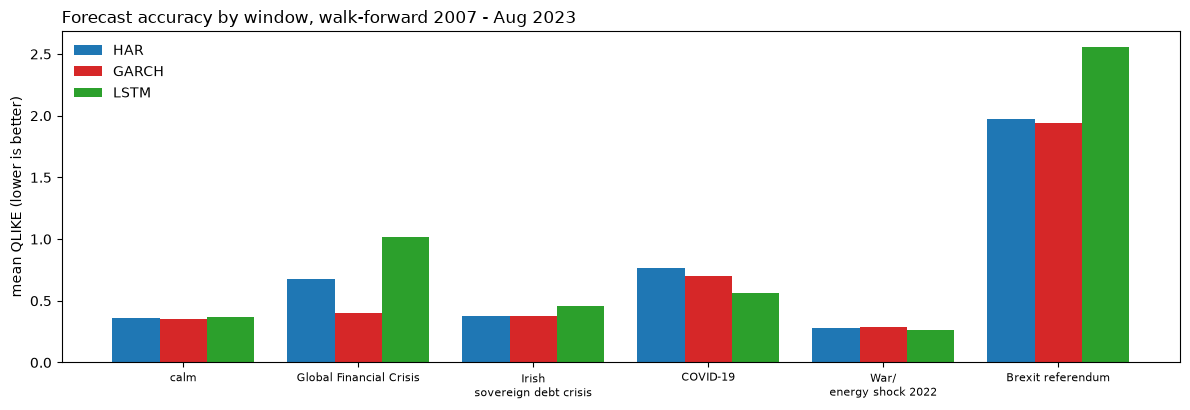

In [39]:
show = ['calm', *[w for w in WINDOWS if w in losses.index]]
fig, ax = plt.subplots(figsize=(12, 4.2))
xpos = np.arange(len(show))
for i, (m, col) in enumerate(zip(['HAR', 'GARCH', 'LSTM'], ['#1f77b4', '#d62728', '#2ca02c'])):
    ax.bar(xpos + (i - 1) * 0.27, losses.loc[show, f'QLIKE {m}'], width=0.27, color=col, label=m)
ax.set_xticks(xpos)
ax.set_xticklabels([s.replace(' sovereign', '\nsovereign').replace(' / ', '/\n') for s in show], fontsize=8)
ax.set_ylabel('mean QLIKE (lower is better)')
ax.legend(frameon=False)
ax.set_title('Forecast accuracy by window, walk-forward 2007 - Aug 2023', loc='left')
plt.tight_layout()
plt.show()

## Learning from history (RQ3, hypothesis H3)
*This time is different?* For each crisis, 5 LSTMs are trained **only on the data before the crisis started** and never updated ("frozen"); they forecast the whole crisis window. Their QLIKE is divided by HAR's QLIKE in the same window: a ratio above 1 means worse than the simple benchmark. The pre-registered expectation (the Minsky test) was that the GFC model, which had seen only the calm 2003–07 boom, would suffer most: GFC > COVID > Irish crisis.

In [40]:
FROZEN = {'Global Financial Crisis': '2007-08-08', 'Irish sovereign debt crisis': '2010-04-22',
          'COVID-19': '2020-02-18'}           # last training day = the day before each window starts
H3_ORDER = ['Global Financial Crisis', 'COVID-19', 'Irish sovereign debt crisis']
if FULL_RUN:
    rows = []
    for crisis, train_end in FROZEN.items():
        days = fc.index[fc['window'] == crisis]
        frozen = np.mean([forecast(fit_model(model_data, train_end, L, H, K, s, device=DEVICE), model_data, days)
                          .to_numpy() for s in SEEDS], axis=0)
        real = fc.loc[days, 'rv5_fwd']
        q_frozen, q_refit, q_har = (qlike(real, frozen).mean(), qlike(real, fc.loc[days, 'LSTM']).mean(),
                                    qlike(real, fc.loc[days, 'HAR']).mean())
        rows.append({'crisis': crisis, 'ratio_frozen_to_HAR': q_frozen / q_har,
                     'ratio_refitted_to_HAR': q_refit / q_har})
    frozen_tab = DataFrame(rows).set_index('crisis')
else:
    frozen_tab = saved('evaluation_frozen.csv').set_index('crisis')
print(frozen_tab[['ratio_frozen_to_HAR', 'ratio_refitted_to_HAR']].round(2))
ranking = list(frozen_tab['ratio_frozen_to_HAR'].sort_values(ascending=False).index)
print('\nObserved ranking:', ' > '.join(ranking))
print('H3 supported:', ranking == H3_ORDER)

                             ratio_frozen_to_HAR  ratio_refitted_to_HAR
crisis                                                                 
Global Financial Crisis                     4.26                   1.51
Irish sovereign debt crisis                 1.33                   1.20
COVID-19                                    0.74                   0.74

Observed ranking: Global Financial Crisis > Irish sovereign debt crisis > COVID-19
H3 supported: False


# 6. Explainable AI — SHAP (RQ2 fingerprints, RQ4 stability)
### The idea
**SHAP** (Lundberg & Lee, 2017) splits one forecast into contributions from each input, using **Shapley values** from game theory — a fair way to share a team's result among its players. The contributions add up to *forecast − average forecast* ("additivity"). For our LSTM each forecast has **132 inputs** (22 days × 6 inputs), so each forecast gets 132 contributions.

* **GradientShap** (Captum library) is the fast SHAP method for neural networks: it averages gradients along paths from **200 background windows** (real days from the model's own training period) to the day being explained, with **1,024 samples**.
* The contributions are made positive (absolute values) and added up by **channel** — domestic (ISEQ inputs), US (S&P 500 inputs), euro (DAX inputs). A **channel share** is that channel's part of the total: which market the model was "listening to".
* A **fingerprint** is the pattern of channel shares in a crisis window. The hypotheses (H2a–H2e) predicted, from each crisis's origin, which shares should **rise above the calm-period share**. "Rises" means the window's **95% block-bootstrap interval** lies entirely above the calm share (blocks of 10 consecutive days keep the time dependence).
* **Stability (H4)**: do the 5 seeds rank the channels the same way (Spearman correlation ≥ 0.8)?

SHAP describes **the model, not the economy**, so the results are called *fingerprints consistent with transmission*, never proof of contagion.

## Method #1 (explain one forecast)
We explain the forecast of the Method #1 model for **16 August 2007**, a day inside the Global Financial Crisis window, and check that the contributions add up.

In [41]:
from captum.attr import GradientShap

CHANNEL = {'ret': 'domestic', 'r2': 'domestic', 'us_ret': 'US', 'us_r2': 'US', 'euro_ret': 'euro', 'euro_r2': 'euro'}
CHANNELS = ['domestic', 'US', 'euro']
CH_IDX = {c: [i for i, k in enumerate(INPUTS) if CHANNEL[k] == c] for c in CHANNELS}
N_SAMPLES, CHUNK, N_BACKGROUND = 1024, 4, 200


def explain(bundle, d, dates, year, seed):
    '''GradientShap attributions (days x 22 x 6) for one model, and the additivity gap per day.'''
    lookback, dev = bundle['lookback'], bundle['device']
    X = ((d[bundle['inputs']] - bundle['mu']) / bundle['sd']).to_numpy(np.float32)
    fit_pos, _ = split_positions(d, bundle['train_end'], lookback)
    rng = np.random.default_rng(1000 * year + seed)
    bg = torch.tensor(windows(X, rng.choice(fit_pos, N_BACKGROUND, replace=False), lookback)).to(dev)
    xe = torch.tensor(windows(X, d.index.get_indexer(pd.DatetimeIndex(dates)), lookback)).to(dev)
    torch.manual_seed(seed)
    np.random.seed(seed)                       # Captum draws its random points with numpy: fix it for repeatability
    gs = GradientShap(bundle['model'])
    attr = np.concatenate([gs.attribute(xe[i:i + CHUNK], baselines=bg, n_samples=N_SAMPLES, stdevs=0.0)
                           .detach().cpu().numpy() for i in range(0, len(xe), CHUNK)])
    with torch.no_grad():
        gap = attr.sum(axis=(1, 2)) - (bundle['model'](xe).cpu().numpy() - bundle['model'](bg).cpu().numpy().mean())
    return attr, gap


attr1, gap1 = explain(LSTM_Regressor1, model_data, ['2007-08-16'], 2007, 1)
a = np.abs(attr1[0])                                   # 22 days x 6 inputs
shares1 = {c: a[:, CH_IDX[c]].sum() / a.sum() for c in CHANNELS}
print('Channel shares for 16 Aug 2007:', {c: round(float(v), 3) for c, v in shares1.items()})
print('Additivity gap (should be close to 0):', round(float(abs(gap1[0])), 4))

Channel shares for 16 Aug 2007: {'domestic': 0.499, 'US': 0.282, 'euro': 0.219}
Additivity gap (should be close to 0): 0.0165


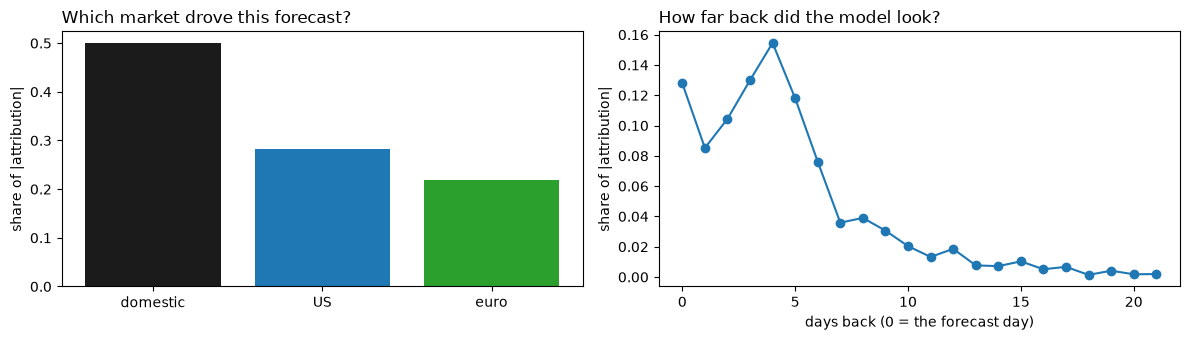

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.bar(CHANNELS, [shares1[c] for c in CHANNELS], color=['#1b1b1b', '#1f77b4', '#2ca02c'])
ax1.set_ylabel('share of |attribution|')
ax1.set_title('Which market drove this forecast?', loc='left')
ax2.plot(range(22), a.sum(axis=1)[::-1] / a.sum(), marker='o')
ax2.set_xlabel('days back (0 = the forecast day)')
ax2.set_ylabel('share of |attribution|')
ax2.set_title('How far back did the model look?', loc='left')
plt.tight_layout()
plt.show()

## Method #2 (all windows, all 5 seeds)
Every day in each crisis window plus every 10th calm day (1,547 days) is explained with the model that actually made its forecast (right year, each seed). With `FULL_RUN = True` this is recomputed here (it needs the 85 models from Section 5); otherwise the saved tables are loaded. Then the pre-registered rules give the verdicts.

In [43]:
from scipy.stats import spearmanr

WINDOW_ORDER = ['calm', 'Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19', 'War / energy shock 2022']


def block_bootstrap(per_day, n_boot=1000, block=10, seed=0):
    '''95% interval of channel shares; per_day = (n_days, 3) channel |attribution| sums in date order.'''
    rng = np.random.default_rng(seed)
    n = len(per_day)
    starts = np.arange(0, n - block + 1)
    draws = []
    for _ in range(n_boot):
        idx = np.concatenate([np.arange(s, s + block) for s in rng.choice(starts, int(np.ceil(n / block)))])[:n]
        s = per_day[idx].sum(axis=0)
        draws.append(s / s.sum())
    return np.percentile(draws, [2.5, 97.5], axis=0)


if FULL_RUN:
    calm = lstm_fc.index[lstm_fc['window'] == 'calm'][::10]
    pick = lstm_fc.index[lstm_fc['window'].isin(WINDOW_ORDER[1:])].union(calm)
    A = {s: {} for s in SEEDS}
    for year, days in pd.Series(pick, index=pick).groupby(pick.year):
        for seed in SEEDS:
            attr, _ = explain(bundles[(year, seed)], model_data, list(days), year, seed)
            for dt, at in zip(days, attr):
                A[seed][dt] = at
        print(year, 'explained')
    days = pd.DatetimeIndex(sorted(A[SEEDS[0]]))
    win = lstm_fc.loc[days, 'window']
    abs_all = np.stack([np.stack([np.abs(A[s][dt]) for dt in days]) for s in SEEDS])   # seeds x days x 22 x 6
    abs_mean = abs_all.mean(axis=0)
    rows, stab_rows = [], []
    for w in WINDOW_ORDER:
        m = (win == w).to_numpy()
        a = abs_mean[m]
        per_day = np.stack([a[:, :, CH_IDX[c]].sum(axis=(1, 2)) for c in CHANNELS], axis=1)
        sh = [a[:, :, CH_IDX[c]].sum() / a.sum() for c in CHANNELS]
        lo, hi = block_bootstrap(per_day)
        for i, c in enumerate(CHANNELS):
            rows.append({'window': w, 'channel': c, 'days': int(m.sum()), 'share': sh[i],
                         'ci_low': lo[i], 'ci_high': hi[i]})
        by_seed = np.stack([[abs_all[i][m][:, :, CH_IDX[c]].sum() / abs_all[i][m].sum() for c in CHANNELS]
                            for i in range(len(SEEDS))])
        rho = [spearmanr(by_seed[i], by_seed[j])[0] for i, j in itertools.combinations(range(len(SEEDS)), 2)]
        stab_rows.append({'window': w, 'mean_spearman_channels': np.nanmean(rho)})
    shap_ch = DataFrame(rows)
    shap_stab = DataFrame(stab_rows).set_index('window')
else:
    shap_ch = saved('shap_channel_shares.csv')
    shap_stab = saved('shap_stability.csv').set_index('window')
shap_ch.to_csv(OUT + 'shap_channel_shares.csv', index=False)
shap_ch.assign(share_with_CI=shap_ch.apply(lambda r: f'{r.share:.3f} [{r.ci_low:.3f}, {r.ci_high:.3f}]', axis=1)) \
       .pivot(index='window', columns='channel', values='share_with_CI').reindex(WINDOW_ORDER)[CHANNELS]

channel,domestic,US,euro
window,,,
calm,"0.523 [0.502, 0.541]","0.266 [0.256, 0.279]","0.211 [0.195, 0.226]"
Global Financial Crisis,"0.482 [0.448, 0.509]","0.299 [0.282, 0.321]","0.219 [0.203, 0.238]"
Irish sovereign debt crisis,"0.512 [0.493, 0.532]","0.252 [0.239, 0.266]","0.236 [0.220, 0.253]"
COVID-19,"0.488 [0.468, 0.508]","0.332 [0.313, 0.355]","0.180 [0.161, 0.196]"
War / energy shock 2022,"0.540 [0.521, 0.560]","0.317 [0.293, 0.341]","0.143 [0.134, 0.154]"


In [44]:
get = lambda w, c, k='share': shap_ch[(shap_ch.window == w) & (shap_ch.channel == c)][k].iloc[0]
rises = lambda w, c: get(w, c, 'ci_low') > get('calm', c)
gfc = {c: get('Global Financial Crisis', c) - get('calm', c) for c in CHANNELS}
spread = lambda w: max(get(w, c) for c in CHANNELS) - min(get(w, c) for c in CHANNELS)
verdicts = [
    ('H2a GFC: US share rises most; domestic above calm',
     max(gfc, key=gfc.get) == 'US' and rises('Global Financial Crisis', 'US') and rises('Global Financial Crisis', 'domestic')),
    ('H2b Irish debt crisis: euro and domestic rise; US below its GFC level',
     rises('Irish sovereign debt crisis', 'euro') and rises('Irish sovereign debt crisis', 'domestic')
     and get('Irish sovereign debt crisis', 'US') < get('Global Financial Crisis', 'US')),
    ('H2c COVID: shares move towards equality (smaller spread than calm)', spread('COVID-19') < spread('calm')),
    ('H2e 2022 shock: euro share rises', rises('War / energy shock 2022', 'euro')),
    ('H4 stability: mean Spearman >= 0.8 in every window', bool((shap_stab['mean_spearman_channels'] >= 0.8).all())),
]
DataFrame(verdicts, columns=['hypothesis', 'supported'])

,hypothesis,supported
0,H2a GFC: US share rises most; domestic above calm,False
1,H2b Irish debt crisis: euro and domestic rise;...,False
2,H2c COVID: shares move towards equality (small...,True
3,H2e 2022 shock: euro share rises,False
4,H4 stability: mean Spearman >= 0.8 in every wi...,False


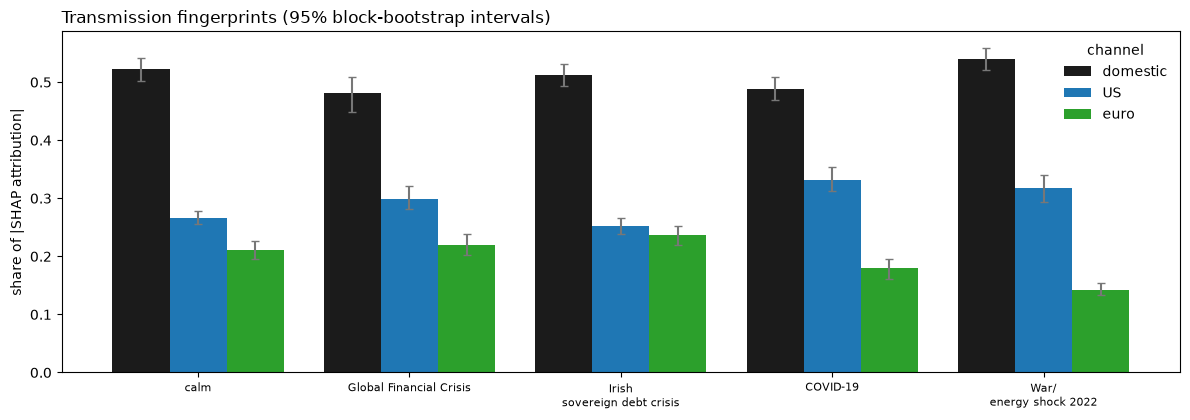

In [45]:
colours = {'domestic': '#1b1b1b', 'US': '#1f77b4', 'euro': '#2ca02c'}
fig, ax = plt.subplots(figsize=(12, 4.3))
xpos = np.arange(len(WINDOW_ORDER))
for i, c in enumerate(CHANNELS):
    sub = shap_ch[shap_ch.channel == c].set_index('window').reindex(WINDOW_ORDER)
    ax.bar(xpos + (i - 1) * 0.27, sub['share'], 0.27, color=colours[c], label=c,
           yerr=[sub['share'] - sub['ci_low'], sub['ci_high'] - sub['share']], capsize=3, ecolor='#777')
ax.set_xticks(xpos)
ax.set_xticklabels([w.replace(' sovereign', '\nsovereign').replace(' / ', '/\n') for w in WINDOW_ORDER], fontsize=8)
ax.set_ylabel('share of |SHAP attribution|')
ax.legend(frameon=False, title='channel')
ax.set_title('Transmission fingerprints (95% block-bootstrap intervals)', loc='left')
plt.tight_layout()
plt.show()

# 7. Robustness check — a different measure of the truth (Parkinson)
All scores so far compare forecasts with realised variance from **closing prices**. Would the ranking change with a different measure? The **Parkinson** estimator uses each day's **high and low** prices: $\sigma^2_{P} = \dfrac{(\ln H - \ln L)^2}{4\ln 2}$. Because the high–low range misses the overnight move, it is scaled to the close-to-close level using 2003–2006 only (before any test day). The forecasts stay the same; only the "truth" they are scored against changes.

In [46]:
park = log(data1['High'] / data1['Low']) ** 2 / (4 * log(2))
park5 = park.shift(-1) + park.shift(-2) + park.shift(-3) + park.shift(-4) + park.shift(-5)
rv5 = np.exp(model_data['log_rv5_fwd'])
pre = slice('2003-01-01', '2006-12-31')
scale = rv5.loc[pre].mean() / park5.loc[pre].reindex(rv5.loc[pre].index).mean()
fc_p = fc.copy()
fc_p['rv5_fwd'] = scale * park5.reindex(fc_p.index)
fc_p = fc_p[fc_p['rv5_fwd'] > 0].dropna(subset=['rv5_fwd'])
print('Parkinson scale factor =', round(scale, 3), '|', len(fc_p), 'days')
park_losses = loss_table(fc_p, ['LSTM', 'GARCH', 'HAR'])
old = saved('robust_parkinson_losses.csv')
if old is not None:
    check('Parkinson losses', park_losses.filter(like='QLIKE'),
          old.set_index('window').reindex(park_losses.index).filter(like='QLIKE'))
for b in ['GARCH', 'HAR']:
    t = dm_hln(qlike(fc_p['rv5_fwd'], fc_p['LSTM']), qlike(fc_p['rv5_fwd'], fc_p[b]))
    print(f'LSTM vs {b}: statistic', round(t['stat'], 2), '| p =', round(t['p_value'], 4))
park_losses.filter(like='QLIKE').round(3)

Parkinson scale factor = 1.001 | 4230 days
Check against the saved results (Parkinson losses): largest difference = 2.00e-06
LSTM vs GARCH: statistic 3.26 | p = 0.0011
LSTM vs HAR: statistic 1.5 | p = 0.1334


,QLIKE LSTM,QLIKE GARCH,QLIKE HAR
window,,,
All test days (2007 - Aug 2023),0.295,0.237,0.270
calm,0.224,0.208,0.229
Global Financial Crisis,0.638,0.256,0.416
Irish sovereign debt crisis,0.276,0.232,0.255
COVID-19,0.315,0.509,0.525
War / energy shock 2022,0.250,0.161,0.163
Brexit referendum,2.368,1.883,1.872


# 8. Exploratory extension E1 — a second lens: Diebold–Yilmaz spillovers
*Exploratory: added after the main results (PREREGISTRATION.md, Amendment A1); no pass/fail rule.*

SHAP asks which markets the **neural network** listens to. The **Diebold–Yilmaz** spillover index (2012) asks a simple **linear model** — a vector autoregression (VAR) — how much of the uncertainty in forecasting the ISEQ's volatility comes from shocks in each market:

1. Each market's log 5-day volatility is regressed on the last 4 days of all three markets (a **VAR(4)**, estimated by OLS).
2. The **generalized forecast-error variance decomposition** (Pesaran & Shin, 1998) splits the 10-day forecast uncertainty of the ISEQ into parts caused by ISEQ, US and DAX shocks; each row is rescaled to add up to 1.
3. This is repeated on a **200-day rolling window**, and the ISEQ row is averaged over the same days that SHAP explained.

If the two very different tools tell the same story, the story is more believable; where they disagree, we learn what each one measures.

In [47]:
def var_ols(Y, p):
    '''VAR(p) with a constant by OLS: lag matrices B_1..B_p and the residual covariance.'''
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - j:T - j] for j in range(1, p + 1)])
    coef = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    resid = Y[p:] - X @ coef
    sigma = resid.T @ resid / (T - p - X.shape[1])
    B = [coef[1 + (j - 1) * k: 1 + j * k].T for j in range(1, p + 1)]
    return B, sigma


def gfevd(B, sigma, h=10):
    '''Generalized FEVD, each row normalised to add up to 1.'''
    k, p = sigma.shape[0], len(B)
    A = [np.eye(k)]
    for s in range(1, h):
        A.append(sum(B[j] @ A[s - 1 - j] for j in range(min(p, s))))
    num = sum((a @ sigma) ** 2 for a in A) / np.diag(sigma)
    den = sum(np.diag(a @ sigma @ a.T) for a in A)
    theta = num / den[:, None]
    return theta / theta.sum(axis=1, keepdims=True)


vol = np.log(dataset.loc[:SAMPLE_END, ['r2', 'us_r2', 'euro_r2']].rolling(5).mean().clip(lower=1e-8)).dropna()
vol.columns = CHANNELS
Y = vol.to_numpy()
rows = []
for i in range(199, len(Y)):
    th = gfevd(*var_ols(Y[i - 199: i + 1], 4))
    rows.append([*th[0], 100 * (th.sum() - np.trace(th)) / 3])
dy_roll = DataFrame(rows, index=vol.index[199:], columns=[*CHANNELS, 'total_spillover'])

calm = lstm_fc.index[lstm_fc['window'] == 'calm'][::10]
shap_days = lstm_fc.index[lstm_fc['window'].isin(WINDOW_ORDER[1:])].union(calm)
dy = dy_roll.reindex(shap_days).groupby(lstm_fc.loc[shap_days, 'window']).mean().reindex(WINDOW_ORDER)
shap_tab = shap_ch.pivot(index='window', columns='channel', values='share').reindex(WINDOW_ORDER)[CHANNELS]
old = saved('connectedness_vs_shap.csv')
if old is not None:
    old = old[old['spec'] == 'main'].pivot(index='window', columns='channel', values='dy_share').reindex(WINDOW_ORDER)
    check('Diebold-Yilmaz shares', dy[CHANNELS], old[CHANNELS])
compare = pd.concat({'SHAP': shap_tab, 'Diebold-Yilmaz': dy[CHANNELS]}, axis=1)
compare.round(3)

Check against the saved results (Diebold-Yilmaz shares): largest difference = 4.44e-05


SHAP               Diebold-Yilmaz         \
channel                     domestic     US   euro       domestic     US   
window                                                                     
calm                           0.523  0.266  0.211          0.655  0.124   
Global Financial Crisis        0.482  0.299  0.219          0.672  0.199   
Irish sovereign debt crisis    0.512  0.252  0.236          0.551  0.206   
COVID-19                       0.488  0.332  0.180          0.427  0.354   
War / energy shock 2022        0.540  0.317  0.143          0.512  0.107   

                                    
channel                       euro  
window                              
calm                         0.221  
Global Financial Crisis      0.129  
Irish sovereign debt crisis  0.243  
COVID-19                     0.219  
War / energy shock 2022      0.381

In [48]:
signs = [np.sign(shap_tab.loc[w, c] - shap_tab.loc['calm', c]) == np.sign(dy.loc[w, c] - dy.loc['calm', c])
         for w in WINDOW_ORDER[1:] for c in ('US', 'euro')]
ranks = [(shap_tab.loc[w, 'US'] > shap_tab.loc[w, 'euro']) == (dy.loc[w, 'US'] > dy.loc[w, 'euro']) for w in WINDOW_ORDER]
print('Same direction of change from calm:', sum(signs), 'of 8')
print('Same US-vs-euro ranking           :', sum(ranks), 'of 5')
print('Total spillover index by window (%):', dy['total_spillover'].round(1).to_dict())

Same direction of change from calm: 4 of 8
Same US-vs-euro ranking           : 2 of 5
Total spillover index by window (%): {'calm': 32.6, 'Global Financial Crisis': 32.5, 'Irish sovereign debt crisis': 42.7, 'COVID-19': 49.5, 'War / energy shock 2022': 42.7}


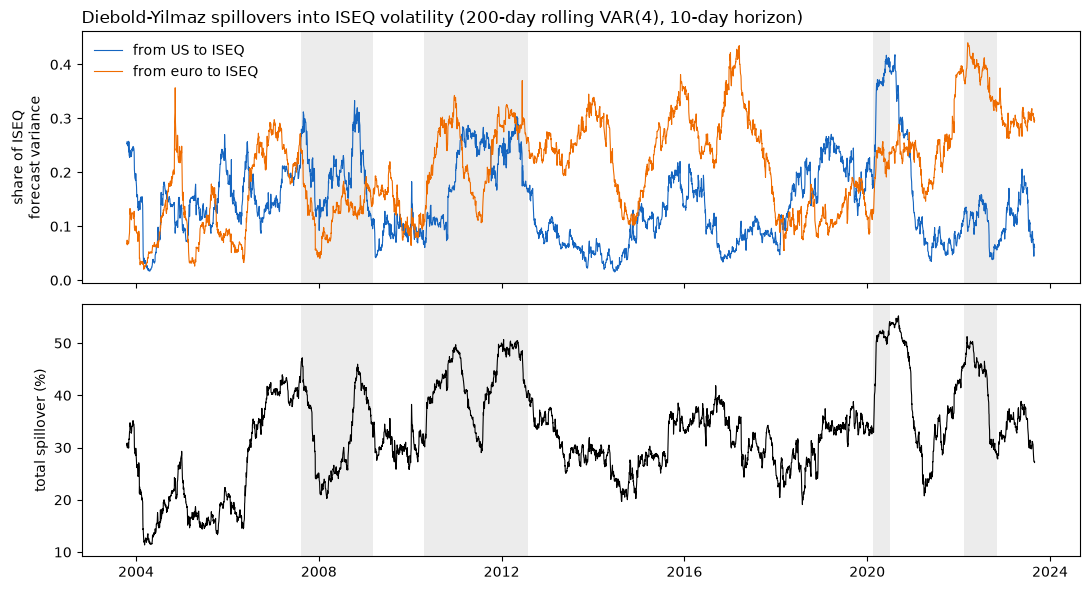

In [49]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
a1.plot(dy_roll['US'], lw=0.8, color='#1565c0', label='from US to ISEQ')
a1.plot(dy_roll['euro'], lw=0.8, color='#ef6c00', label='from euro to ISEQ')
a2.plot(dy_roll['total_spillover'], lw=0.8, color='black')
for ax in (a1, a2):
    for name, (a, b) in WINDOWS.items():
        if name != 'Brexit referendum':
            ax.axvspan(Timestamp(a), Timestamp(b), color='grey', alpha=0.15, lw=0)
a1.set_ylabel('share of ISEQ\nforecast variance')
a1.legend(frameon=False)
a2.set_ylabel('total spillover (%)')
a1.set_title('Diebold-Yilmaz spillovers into ISEQ volatility (200-day rolling VAR(4), 10-day horizon)', loc='left')
plt.tight_layout()
plt.show()

# 9. Exploratory extension E2 — was there calm before the storm?
*Exploratory: added after the main results (PREREGISTRATION.md, Amendment A1).*

Danielsson, Valenzuela & Zer (2018) studied 60 countries over up to 211 years and found that **long spells of volatility below its trend** — not high volatility — came before banking crises: calm encourages borrowing and risk ("stability is destabilising", Minsky). We apply their measure market by market. A long history is needed to estimate a trend, so this step uses **monthly** share prices from the OECD (via FRED): Ireland from 1955 (the ISEQ), the US from 1957 and Germany from 1960.

1. Monthly log returns, with the most extreme 0.5% at each end capped (winsorised).
2. **Annual volatility** = standard deviation of the 12 monthly returns from July to June × √12.
3. **One-sided Hodrick–Prescott trend** (λ = 5,000): for each year the trend is fitted to past years only.
4. $\delta^{low}$ = volatility minus trend when below the trend (else 0); the measure is its **average over the five years before a crisis**, and its **percentile** within the market's own history. Bottom 20% = "unusually calm".

In [50]:
from statsmodels.tsa.filters.hp_filter import hpfilter

FRED = {'Ireland': 'SPASTT01IEM661N', 'United States': 'SPASTT01USM661N', 'Germany': 'SPASTT01DEM661N'}
YAHOO = {'Ireland': data1, 'United States': data2, 'Germany': data3}
CRISIS_YEAR = {'Global Financial Crisis': 2008, 'Irish sovereign debt crisis': 2010, 'COVID-19': 2020}
vol_year = lambda idx: idx.year + (idx.month >= 7)          # July 2006 - June 2007 = year 2007

rows, check_rows = [], []
for market, code_ in FRED.items():
    prices = read_csv(DATA + f'FRED_{code_}.csv', index_col=0, parse_dates=True).iloc[:, 0]
    prices = pd.to_numeric(prices, errors='coerce').dropna().loc[:'2023-06-30']
    r = np.log(prices).diff().dropna()
    r = r.clip(r.quantile(0.005), r.quantile(0.995))                              # winsorise
    g = r.groupby(vol_year(r.index))
    sigma = (g.std() * np.sqrt(12))[g.size() == 12]                               # annual volatility
    x_ = sigma.to_numpy()
    trend = Series([hpfilter(x_[:t + 1], lamb=5000)[1][-1] for t in range(9, len(x_))], index=sigma.index[9:])
    low = (sigma - trend).dropna().clip(upper=0)                                  # below-trend part
    low5 = low.rolling(5).mean().shift(1)                                         # mean of the previous 5 years
    low5.loc[low5.index.max() + 1] = low.iloc[-5:].mean()
    hist = low5.dropna()
    for crisis, year in CRISIS_YEAR.items():
        v = hist.loc[year]
        pct = 100 * (hist <= v).mean()
        rows.append({'market': market, 'crisis': crisis, 'years used': f'{year - 5}-{year - 1}',
                     'mean below-trend vol': round(v, 3), 'percentile': round(pct, 1),
                     'unusually calm': pct <= 20})
    d_ = np.log(YAHOO[market]['Close']).diff().dropna().loc[:'2023-06-30']
    y_vol = (d_.groupby(vol_year(d_.index)).std() * np.sqrt(252)).loc[2004:2023]
    check_rows.append({'market': market, 'corr FRED vs Yahoo (2004-2023)': round(sigma.loc[y_vol.index].corr(y_vol), 3)})

paradox = DataFrame(rows)
old = saved('volatility_paradox_crises.csv')
if old is not None:
    check('volatility-paradox measure', paradox['mean below-trend vol'], old['low5_before'].round(3))
print(DataFrame(check_rows).to_string(index=False))
paradox

Check against the saved results (volatility-paradox measure): largest difference = 0.00e+00
       market  corr FRED vs Yahoo (2004-2023)
      Ireland                           0.902
United States                           0.911
      Germany                           0.886


,market,crisis,years used,mean below-trend vol,percentile,unusually calm
0,Ireland,Global Financial Crisis,2003-2007,-0.032,40.0,False
1,Ireland,Irish sovereign debt crisis,2005-2009,-0.019,61.8,False
2,Ireland,COVID-19,2015-2019,-0.020,60.0,False
3,United States,Global Financial Crisis,2003-2007,-0.022,41.5,False
4,United States,Irish sovereign debt crisis,2005-2009,-0.017,60.4,False
5,United States,COVID-19,2015-2019,-0.020,49.1,False
6,Germany,Global Financial Crisis,2003-2007,-0.049,4.0,True
7,Germany,Irish sovereign debt crisis,2005-2009,-0.036,16.0,True
8,Germany,COVID-19,2015-2019,-0.027,40.0,False


# 10. Prediction
The class notebooks ended by predicting for a **new** case (`DT_classifier1.predict(new1_scaled)`) and saving the model with `joblib.dump`. Here the "new case" is the week **after the main sample ends**: what did each model forecast on 31 August 2023 for the next five trading days, and what actually happened? The HAR model of the last refit (2023) is then saved, like `joblib.dump(best_svc, 'MysvcModel.pkl')`.

In [51]:
last_day = fc.index[-1]
pred = fc.loc[last_day, ['rv5_fwd', 'LSTM', 'GARCH', 'HAR']]
print('Forecast made on', last_day.date(), 'for the next 5 trading days (annualised volatility):')
for k, v in pred.items():
    print(f"  {'realised' if k == 'rv5_fwd' else k:9s}: {sqrt(v * 252 / 5):.1%}")

Forecast made on 2023-08-31 for the next 5 trading days (annualised volatility):
  realised : 13.3%
  LSTM     : 13.5%
  GARCH    : 14.3%
  HAR      : 15.6%


In [52]:
import joblib
joblib.dump(best_model, OUT + 'HAR_model_2023.pkl')     # the last HAR model (trained to 31 Dec 2022)
HAR_loaded = joblib.load(OUT + 'HAR_model_2023.pkl')
print(HAR_loaded.params.round(3))

const   -0.499
rv_d     0.004
rv_w     0.172
rv_m     0.611
dtype: float64


# 11. Summary of the results
| Question | Result |
|---|---|
| **RQ1 / H1** — is the LSTM more accurate than GARCH and HAR? | **Not supported.** Over 2007–Aug 2023 the LSTM is significantly *less* accurate (QLIKE 0.463 vs GARCH 0.380 and HAR 0.414). It is the most accurate model in COVID-19 and 2022, and the least accurate in the GFC. |
| **RQ2 / H2** — do the SHAP fingerprints follow each crisis's origin? | **Mostly not.** H2a and H2b partly, H2c narrowly supported, H2e not supported; the ISEQ's own history supplies about half of every forecast. |
| **RQ3 / H3** — does a model trained on past crises cope with a new one? | **Not as ranked**, but the GFC model (trained only on the calm boom) was by far the worst: 4.3 × HAR's error; the COVID model beat HAR. |
| **RQ4 / H4** — are the explanations stable across seeds? | **Not supported:** Spearman 0.7 in the GFC and Irish windows. |
| Robustness — Parkinson measure | GARCH still best; the LSTM still best in COVID-19. |
| E1 (exploratory) — SHAP vs Diebold–Yilmaz | Weak agreement: 4 of 8 direction checks, 2 of 5 rankings. |
| E2 (exploratory) — calm before the storm? | Only Germany was unusually calm before the GFC; Ireland was calm but not unusually so. |

Everything this notebook produced is in the `outputs/` folder. The full, pre-registered analysis (with the dated Git history) is in the repository scripts `code/01` … `code/12`; this notebook reproduces the same steps and checks itself against the saved results.